In [1]:
import sys
import os

PROJECT_ROOT = os.path.abspath("..")
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import matplotlib.pyplot as plt

from src.cascade_engine import run_cascade_simulation

In [2]:
base_params = {
    "S0": 100.0,
    "mu": 0.0,
    "sigma": 0.6,        # baseline volatility
    "T": 1.0,
    "N": 252,
    "Q": 1.0,
    "LT": 0.8,
    "oracle_step": 12,
    "eps": 0.02,
    "delta": 0.05,
}

In [3]:
beta_grid = np.linspace(0.01, 0.12, 15)
lambda_grid = np.linspace(0.0005, 0.01, 15)

n_agents = 500
n_seeds = 8

In [4]:
def compute_phase_surface(base_params, beta_grid, lambda_grid,
                          n_agents, n_seeds):
    phase = np.zeros((len(beta_grid), len(lambda_grid)))

    for i, beta in enumerate(beta_grid):
        for j, lam in enumerate(lambda_grid):

            params = base_params.copy()
            params["beta"] = beta
            params["impact_lambda"] = lam

            outcomes = []
            for seed in range(n_seeds):
                res = run_cascade_simulation(
                    params,
                    n_agents=n_agents,
                    seed=seed
                )
                outcomes.append(res["final_liquidation_fraction"])

            phase[i, j] = np.mean(outcomes)

    return phase

In [5]:
phase_baseline = compute_phase_surface(
    base_params,
    beta_grid,
    lambda_grid,
    n_agents,
    n_seeds
)

In [6]:
params_vol_stress = base_params.copy()
params_vol_stress["sigma"] = 1.0   # volatility stress

phase_vol_stress = compute_phase_surface(
    params_vol_stress,
    beta_grid,
    lambda_grid,
    n_agents,
    n_seeds
)

In [11]:
params_liq_stress = base_params.copy()
params_liq_stress["liquidity_factor"] = 0.5

phase_liq_stress = compute_phase_surface(
    params_liq_stress,
    beta_grid,
    lambda_grid,
    n_agents,
    n_seeds
)

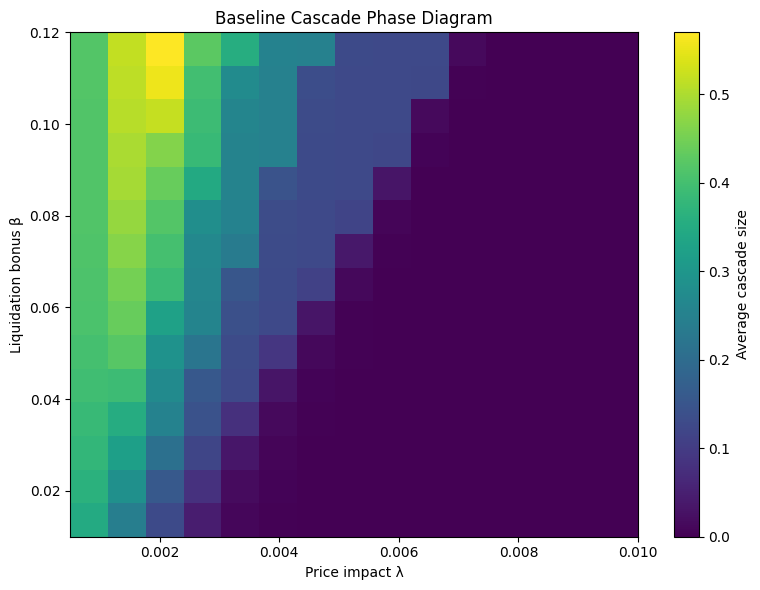

In [8]:
plt.figure(figsize=(8, 6))

plt.imshow(
    phase_baseline,
    origin="lower",
    aspect="auto",
    extent=[
        lambda_grid[0], lambda_grid[-1],
        beta_grid[0], beta_grid[-1],
    ],
    cmap="viridis"
)

plt.colorbar(label="Average cascade size")
plt.xlabel("Price impact λ")
plt.ylabel("Liquidation bonus β")
plt.title("Baseline Cascade Phase Diagram")

plt.tight_layout()
plt.show()

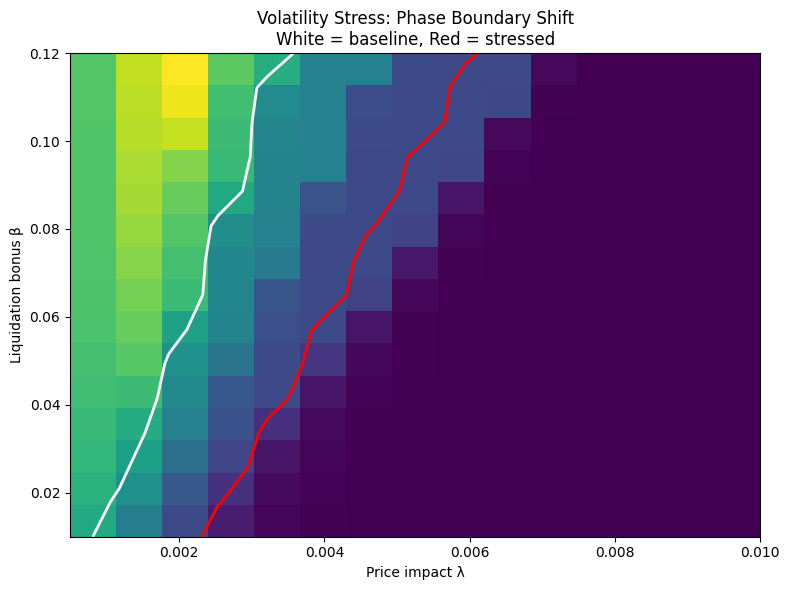

In [9]:
plt.figure(figsize=(8, 6))

plt.imshow(
    phase_baseline,
    origin="lower",
    aspect="auto",
    extent=[
        lambda_grid[0], lambda_grid[-1],
        beta_grid[0], beta_grid[-1],
    ],
    cmap="viridis"
)

plt.contour(
    lambda_grid,
    beta_grid,
    phase_baseline,
    levels=[0.3],
    colors="white",
    linewidths=2,
)

plt.contour(
    lambda_grid,
    beta_grid,
    phase_vol_stress,
    levels=[0.3],
    colors="red",
    linewidths=2,
)

plt.xlabel("Price impact λ")
plt.ylabel("Liquidation bonus β")
plt.title("Volatility Stress: Phase Boundary Shift\nWhite = baseline, Red = stressed")

plt.tight_layout()
plt.show()

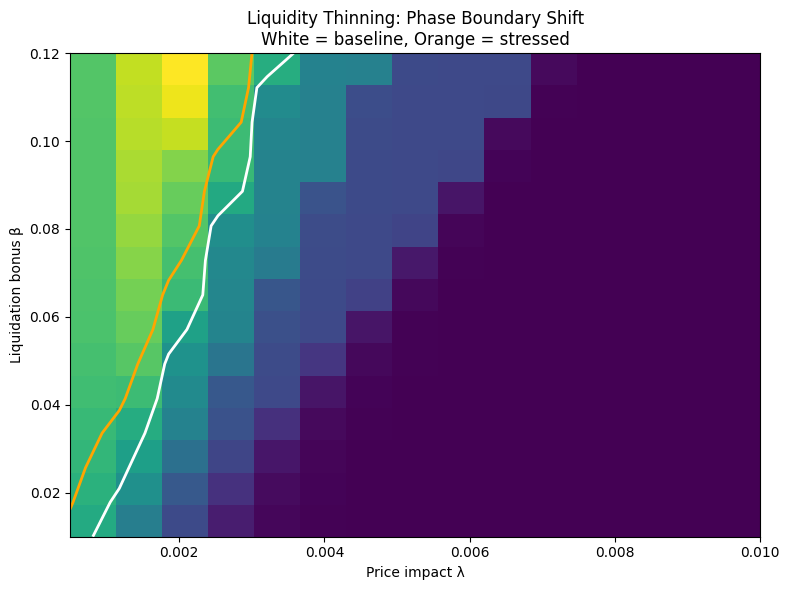

In [12]:
plt.figure(figsize=(8, 6))

plt.imshow(
    phase_baseline,
    origin="lower",
    aspect="auto",
    extent=[
        lambda_grid[0], lambda_grid[-1],
        beta_grid[0], beta_grid[-1],
    ],
    cmap="viridis"
)

plt.contour(
    lambda_grid,
    beta_grid,
    phase_baseline,
    levels=[0.3],
    colors="white",
    linewidths=2,
)

plt.contour(
    lambda_grid,
    beta_grid,
    phase_liq_stress,
    levels=[0.3],
    colors="orange",
    linewidths=2,
)

plt.xlabel("Price impact λ")
plt.ylabel("Liquidation bonus β")
plt.title("Liquidity Thinning: Phase Boundary Shift\nWhite = baseline, Orange = stressed")

plt.tight_layout()
plt.show()


C:\Users\ce81g\AppData\Local\Temp\ipykernel_18952\1562627723.py:16: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(


FileNotFoundError: [Errno 2] No such file or directory: '..figures/overlay_test.png'

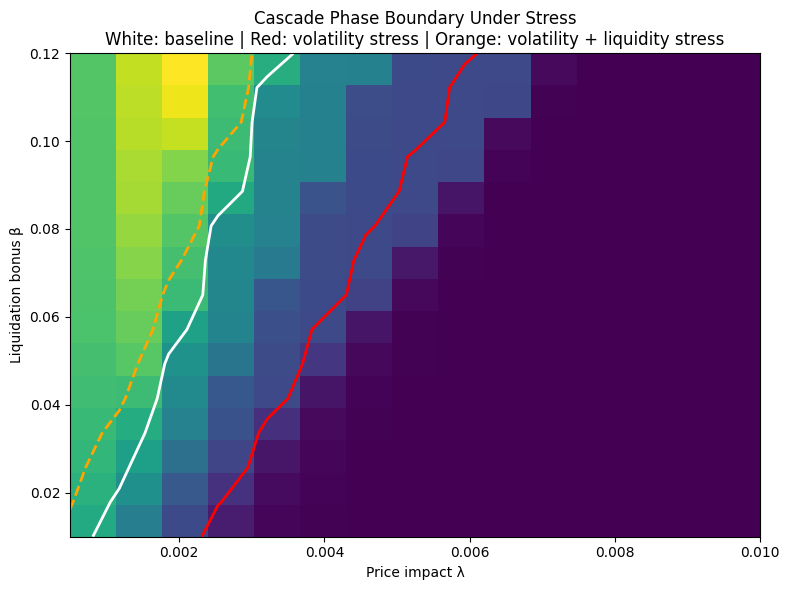

In [ ]:
plt.figure(figsize=(8, 6))

# Background: baseline phase diagram
plt.imshow(
    phase_baseline,
    origin="lower",
    aspect="auto",
    extent=[
        lambda_grid[0], lambda_grid[-1],
        beta_grid[0], beta_grid[-1],
    ],
    cmap="viridis"
)

# Baseline boundary
plt.contour(
    lambda_grid,
    beta_grid,
    phase_baseline,
    levels=[0.3],
    colors="white",
    linewidths=2,
    linestyles="solid",
    label="Baseline"
)

# Volatility stress boundary
plt.contour(
    lambda_grid,
    beta_grid,
    phase_vol_stress,
    levels=[0.3],
    colors="red",
    linewidths=2,
    linestyles="solid"
)

# Volatility + liquidity stress boundary
plt.contour(
    lambda_grid,
    beta_grid,
    phase_liq_stress,
    levels=[0.3],
    colors="orange",
    linewidths=2,
    linestyles="dashed"
)

plt.xlabel("Price impact λ")
plt.ylabel("Liquidation bonus β")
plt.title(
    "Cascade Phase Boundary Under Stress\n"
    "White: baseline | Red: volatility stress | Orange: volatility + liquidity stress"
)

plt.tight_layout()

# ✅ SAVE FIGURE
out_dir = os.path.join(PROJECT_ROOT, "figures")
os.makedirs(out_dir, exist_ok=True)
plt.savefig(os.path.join(out_dir, "overlay_test.png"), dpi=200)


plt.show()